In [1]:
# =========================
# Work6 高难度终版：下载官方带纹理 Cow 数据
# =========================

import os
import urllib.request

tex_data_dir = "data/cow_mesh"
tex_assets_dir = "work6_texture_assets"
tex_mesh_dir = "work6_texture_output_meshes"

os.makedirs(tex_data_dir, exist_ok=True)
os.makedirs(tex_assets_dir, exist_ok=True)
os.makedirs(tex_mesh_dir, exist_ok=True)

files = {
    "cow.obj": "https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.obj",
    "cow.mtl": "https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.mtl",
    "cow_texture.png": "https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow_texture.png",
}

for filename, url in files.items():
    save_path = os.path.join(tex_data_dir, filename)
    if not os.path.exists(save_path):
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(url, save_path)
    else:
        print(f"{filename} already exists.")

print("\n当前纹理牛数据目录：")
!ls -lh data/cow_mesh


当前纹理牛数据目录：
总计 408K
-rw-r--r-- 1 root root  155  5月 14 19:08 cow.mtl
-rw-r--r-- 1 root root 323K  5月 14 19:08 cow.obj
-rw-r--r-- 1 root root  77K  5月 14 19:08 cow_texture.png


In [2]:
# =========================
# Work6 高难度终版：加载 textured cow mesh
# =========================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from IPython.display import clear_output
from tqdm.auto import tqdm

from pytorch3d.io import load_objs_as_meshes, save_obj
from pytorch3d.utils import ico_sphere
from pytorch3d.structures import Meshes
from pytorch3d.loss import (
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    PointLights,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    SoftSilhouetteShader,
    TexturesVertex,
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("当前设备:", device)

tex_obj_path = os.path.join(tex_data_dir, "cow.obj")

# load_objs_as_meshes 会自动读取 obj 中引用的 mtl 和 texture png
tex_target_mesh = load_objs_as_meshes([tex_obj_path], device=device)

# 归一化到原点附近，方便优化
tex_verts = tex_target_mesh.verts_packed()
tex_center = tex_verts.mean(0)
tex_scale = max((tex_verts - tex_center).abs().max(0)[0])

tex_target_mesh.offset_verts_(-tex_center)
tex_target_mesh.scale_verts_(1.0 / float(tex_scale))

print("带纹理 cow mesh 加载成功")
print("顶点数量:", tex_target_mesh.verts_packed().shape)
print("面片数量:", tex_target_mesh.faces_packed().shape)
print("是否包含 textures:", tex_target_mesh.textures is not None)

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


当前设备: cuda:0
带纹理 cow mesh 加载成功
顶点数量: torch.Size([2930, 3])
面片数量: torch.Size([5856, 3])
是否包含 textures: True


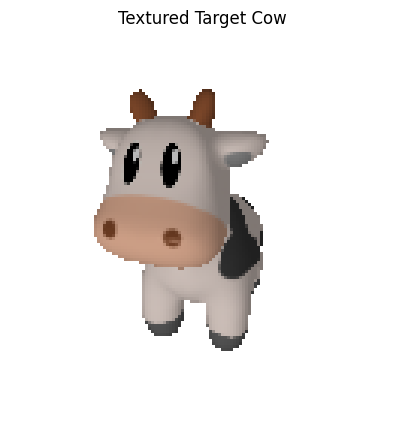

真实纹理目标牛已保存: work6_texture_assets/texture_target_cow.png


In [3]:
# =========================
# Work6 高难度终版：构建 RGB / Silhouette 渲染器并生成目标图像
# =========================

tex_num_views = 20
tex_image_size = 128

tex_elev = torch.linspace(0, 360, tex_num_views, device=device)
tex_azim = torch.linspace(-180, 180, tex_num_views, device=device)

R_tex, T_tex = look_at_view_transform(
    dist=2.7,
    elev=tex_elev,
    azim=tex_azim,
    device=device,
)

tex_cameras = FoVPerspectiveCameras(
    device=device,
    R=R_tex,
    T=T_tex,
)

# 用第 1 个视角做固定展示视角
tex_vis_camera = FoVPerspectiveCameras(
    device=device,
    R=R_tex[None, 1, ...],
    T=T_tex[None, 1, ...],
)

tex_lights = PointLights(
    device=device,
    location=[[0.0, 0.0, -3.0]],
)

# RGB 渲染器
tex_rgb_raster_settings = RasterizationSettings(
    image_size=tex_image_size,
    blur_radius=0.0,
    faces_per_pixel=1,
)

tex_rgb_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=tex_vis_camera,
        raster_settings=tex_rgb_raster_settings,
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=tex_vis_camera,
        lights=tex_lights,
    ),
)

# Soft silhouette 渲染器
tex_sigma = 1e-4
tex_sil_raster_settings = RasterizationSettings(
    image_size=tex_image_size,
    blur_radius=np.log(1.0 / 1e-4 - 1.0) * tex_sigma,
    faces_per_pixel=50,
)

tex_sil_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=tex_vis_camera,
        raster_settings=tex_sil_raster_settings,
    ),
    shader=SoftSilhouetteShader(),
)

# 多视角目标 RGB
tex_meshes = tex_target_mesh.extend(tex_num_views)

with torch.no_grad():
    tex_target_images = tex_rgb_renderer(
        tex_meshes,
        cameras=tex_cameras,
        lights=tex_lights,
    )
    tex_target_rgb = [tex_target_images[i, ..., :3].detach() for i in range(tex_num_views)]

    tex_silhouette_images = tex_sil_renderer(
        tex_meshes,
        cameras=tex_cameras,
        lights=tex_lights,
    )
    tex_target_silhouette = [
        tex_silhouette_images[i, ..., 3].detach()
        for i in range(tex_num_views)
    ]

    tex_target_cameras = [
        FoVPerspectiveCameras(
            device=device,
            R=R_tex[None, i, ...],
            T=T_tex[None, i, ...],
        )
        for i in range(tex_num_views)
    ]

# 展示目标牛
plt.figure(figsize=(5, 5))
plt.imshow(tex_target_rgb[1].detach().cpu().numpy())
plt.title("Textured Target Cow")
plt.axis("off")

tex_target_path = os.path.join(tex_assets_dir, "texture_target_cow.png")
plt.savefig(tex_target_path, dpi=180, bbox_inches="tight")
plt.show()

print("真实纹理目标牛已保存:", tex_target_path)

In [5]:
# =========================
# Work6 高难度终版：可视化辅助函数
# =========================

def tex_visualize_prediction(predicted_mesh, title, save_path=None):
    with torch.no_grad():
        predicted_image = tex_rgb_renderer(
            predicted_mesh,
            cameras=tex_target_cameras[1],
            lights=tex_lights,
        )

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(predicted_image[0, ..., :3].detach().cpu().clamp(0, 1).numpy())
    ax[0].set_title(title)
    ax[0].axis("off")

    ax[1].imshow(tex_target_rgb[1].detach().cpu().numpy())
    ax[1].set_title("Target RGB")
    ax[1].axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")

    plt.show()


def tex_update_mesh_shape_prior_losses(mesh, loss_dict):
    loss_dict["edge"] = mesh_edge_loss(mesh)
    loss_dict["normal"] = mesh_normal_consistency(mesh)
    loss_dict["laplacian"] = mesh_laplacian_smoothing(mesh, method="uniform")

Texture Epoch 1199/1200 | Total: 0.028657 | RGB: 0.017272 | Sil: 0.002740 | Edge: 0.003924 | Normal: 0.023281 | Lap: 0.004489


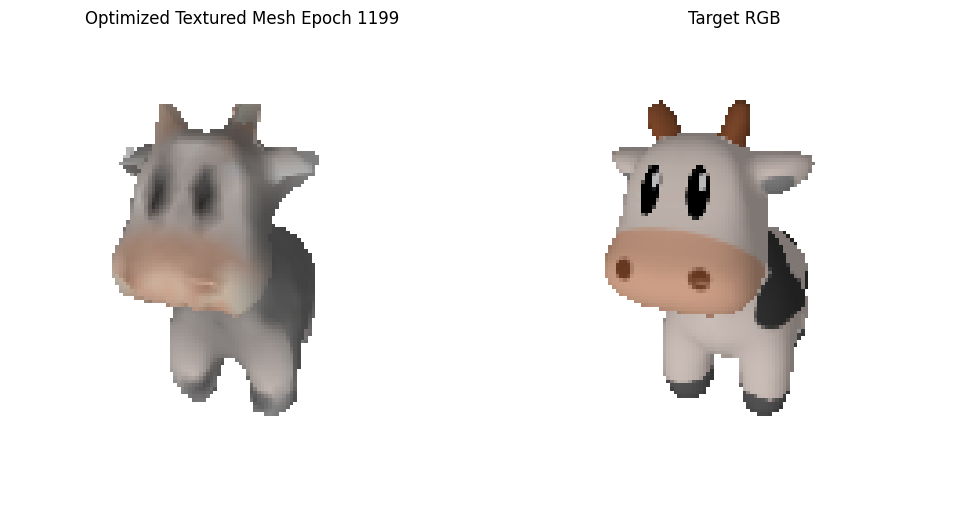

texture_total_loss = 0.028657: 100%|██████████| 1200/1200 [00:42<00:00, 28.08it/s]

真实纹理高难度优化完成。


In [6]:
# =========================
# Work6 高难度终版：Textured Mesh Fitting
# =========================

# 从球体开始
tex_src_mesh = ico_sphere(4, device)

tex_verts_shape = tex_src_mesh.verts_packed().shape

# 优化变量 1：顶点形变
tex_deform_verts = torch.full(
    tex_verts_shape,
    0.0,
    device=device,
    requires_grad=True,
)

# 优化变量 2：球体每个顶点的 RGB 颜色
tex_sphere_verts_rgb = torch.full(
    [1, tex_verts_shape[0], 3],
    0.5,
    device=device,
    requires_grad=True,
)

# 优化器
tex_optimizer = torch.optim.SGD(
    [tex_deform_verts, tex_sphere_verts_rgb],
    lr=1.0,
    momentum=0.9,
)

# 渲染器：使用 SoftPhongShader 做 RGB 可微渲染
tex_soft_raster_settings = RasterizationSettings(
    image_size=tex_image_size,
    blur_radius=np.log(1.0 / 1e-4 - 1.0) * tex_sigma,
    faces_per_pixel=50,
    perspective_correct=False,
)

tex_textured_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=tex_vis_camera,
        raster_settings=tex_soft_raster_settings,
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=tex_vis_camera,
        lights=tex_lights,
    ),
)

# 参数
tex_num_views_per_iteration = 2
tex_Niter = 1200
tex_plot_period = 100

tex_losses = {
    "rgb": {"weight": 1.0, "values": []},
    "silhouette": {"weight": 1.0, "values": []},
    "edge": {"weight": 1.0, "values": []},
    "normal": {"weight": 0.01, "values": []},
    "laplacian": {"weight": 1.0, "values": []},
}

tex_frame_paths = []

print("开始真实纹理高难度优化：sphere -> textured cow")

loop = tqdm(range(tex_Niter))

for i in loop:
    tex_optimizer.zero_grad()

    # 形变球体
    tex_new_src_mesh = tex_src_mesh.offset_verts(tex_deform_verts)

    # 给球体加上可学习顶点颜色
    tex_new_src_mesh.textures = TexturesVertex(
        verts_features=tex_sphere_verts_rgb.clamp(0.0, 1.0)
    )

    # 初始化 loss
    tex_loss = {
        k: torch.tensor(0.0, device=device)
        for k in tex_losses
    }

    # 几何正则化
    tex_update_mesh_shape_prior_losses(tex_new_src_mesh, tex_loss)

    # 随机选多个视角监督
    selected_views = np.random.permutation(tex_num_views).tolist()[:tex_num_views_per_iteration]

    for j in selected_views:
        tex_images_predicted = tex_textured_renderer(
            tex_new_src_mesh,
            cameras=tex_target_cameras[j],
            lights=tex_lights,
        )

        # Silhouette loss
        tex_predicted_silhouette = tex_images_predicted[..., 3]
        tex_loss_silhouette = (
            (tex_predicted_silhouette - tex_target_silhouette[j]) ** 2
        ).mean()

        tex_loss["silhouette"] += tex_loss_silhouette / tex_num_views_per_iteration

        # RGB loss
        tex_predicted_rgb = tex_images_predicted[..., :3]
        tex_loss_rgb = (
            (tex_predicted_rgb - tex_target_rgb[j]) ** 2
        ).mean()

        tex_loss["rgb"] += tex_loss_rgb / tex_num_views_per_iteration

    # 加权总 loss
    tex_sum_loss = torch.tensor(0.0, device=device)

    for k, loss_value in tex_loss.items():
        tex_sum_loss += loss_value * tex_losses[k]["weight"]
        tex_losses[k]["values"].append(float(loss_value.detach().cpu()))

    loop.set_description(f"texture_total_loss = {tex_sum_loss.item():.6f}")

    tex_sum_loss.backward()
    tex_optimizer.step()

    # 保存中间图
    if i % tex_plot_period == 0 or i == tex_Niter - 1:
        clear_output(wait=True)

        print(
            f"Texture Epoch {i:04d}/{tex_Niter} | "
            f"Total: {tex_sum_loss.item():.6f} | "
            f"RGB: {tex_loss['rgb'].item():.6f} | "
            f"Sil: {tex_loss['silhouette'].item():.6f} | "
            f"Edge: {tex_loss['edge'].item():.6f} | "
            f"Normal: {tex_loss['normal'].item():.6f} | "
            f"Lap: {tex_loss['laplacian'].item():.6f}"
        )

        frame_path = os.path.join(
            tex_assets_dir,
            f"texture_fit_epoch_{i:04d}.png"
        )

        tex_visualize_prediction(
            tex_new_src_mesh,
            title=f"Optimized Textured Mesh Epoch {i}",
            save_path=frame_path,
        )

        tex_frame_paths.append(frame_path)

print("真实纹理高难度优化完成。")

真实纹理优化 GIF 已保存: work6_texture_assets/texture_fit_optimization.gif


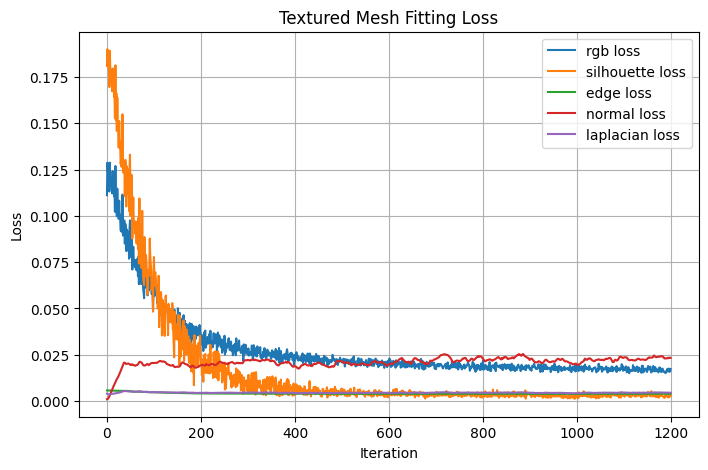

真实纹理 Loss 曲线已保存: work6_texture_assets/texture_fit_loss_curve.png


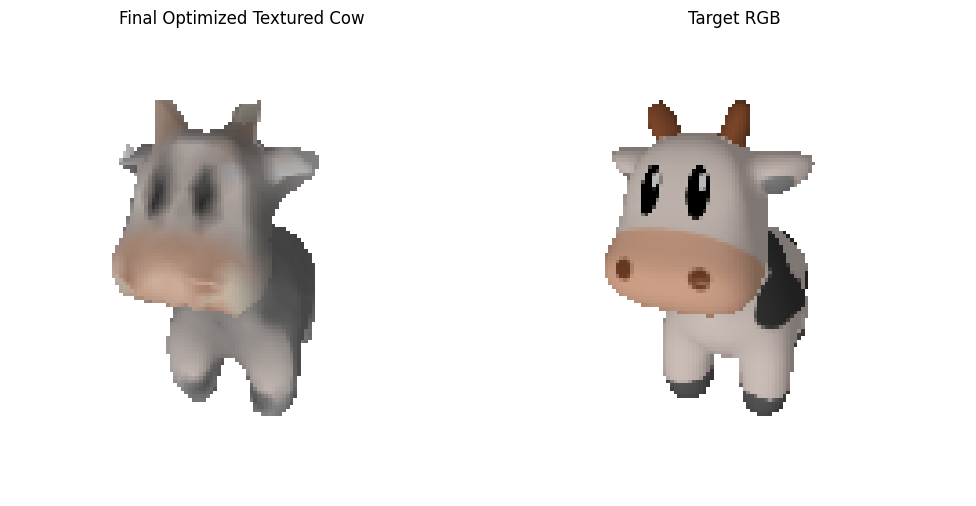

真实纹理最终对比图已保存: work6_texture_assets/texture_final_compare.png
真实纹理最终 OBJ 已保存: work6_texture_output_meshes/final_texture_fit_model.obj


/usr/local/lib/python3.11/site-packages/pytorch3d/io/obj_io.py:841: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  vert = [float_str % verts[i, j] for j in range(D)]


In [7]:
# =========================
# Work6 高难度终版：保存结果
# =========================

# 最终 mesh
tex_final_mesh = tex_src_mesh.offset_verts(tex_deform_verts)
tex_final_mesh.textures = TexturesVertex(
    verts_features=tex_sphere_verts_rgb.detach().clamp(0.0, 1.0)
)

# 保存 GIF
tex_gif_path = os.path.join(tex_assets_dir, "texture_fit_optimization.gif")

tex_frames = [imageio.imread(path) for path in tex_frame_paths]
imageio.mimsave(tex_gif_path, tex_frames, fps=4)

print("真实纹理优化 GIF 已保存:", tex_gif_path)

# 保存 loss 曲线
plt.figure(figsize=(8, 5))

for k, loss_info in tex_losses.items():
    plt.plot(loss_info["values"], label=f"{k} loss")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Textured Mesh Fitting Loss")
plt.legend()
plt.grid(True)

tex_loss_curve_path = os.path.join(tex_assets_dir, "texture_fit_loss_curve.png")
plt.savefig(tex_loss_curve_path, dpi=180, bbox_inches="tight")
plt.show()

print("真实纹理 Loss 曲线已保存:", tex_loss_curve_path)

# 保存最终对比图
tex_final_compare_path = os.path.join(tex_assets_dir, "texture_final_compare.png")

tex_visualize_prediction(
    tex_final_mesh,
    title="Final Optimized Textured Cow",
    save_path=tex_final_compare_path,
)

print("真实纹理最终对比图已保存:", tex_final_compare_path)

# 保存最终 obj
tex_final_verts, tex_final_faces = tex_final_mesh.get_mesh_verts_faces(0)

tex_final_obj_path = os.path.join(
    tex_mesh_dir,
    "final_texture_fit_model.obj"
)

save_obj(
    tex_final_obj_path,
    tex_final_verts,
    tex_final_faces,
)

print("真实纹理最终 OBJ 已保存:", tex_final_obj_path)

In [8]:
!find work6_texture_assets -maxdepth 1 -type f | sort
!find work6_texture_output_meshes -maxdepth 1 -type f | sort

work6_texture_assets/texture_final_compare.png
work6_texture_assets/texture_fit_epoch_0000.png
work6_texture_assets/texture_fit_epoch_0100.png
work6_texture_assets/texture_fit_epoch_0200.png
work6_texture_assets/texture_fit_epoch_0300.png
work6_texture_assets/texture_fit_epoch_0400.png
work6_texture_assets/texture_fit_epoch_0500.png
work6_texture_assets/texture_fit_epoch_0600.png
work6_texture_assets/texture_fit_epoch_0700.png
work6_texture_assets/texture_fit_epoch_0800.png
work6_texture_assets/texture_fit_epoch_0900.png
work6_texture_assets/texture_fit_epoch_1000.png
work6_texture_assets/texture_fit_epoch_1100.png
work6_texture_assets/texture_fit_epoch_1199.png
work6_texture_assets/texture_fit_loss_curve.png
work6_texture_assets/texture_fit_optimization.gif
work6_texture_assets/texture_target_cow.png
work6_texture_output_meshes/final_texture_fit_model.obj


In [ ]:
import os
import shutil
from pathlib import Path

package_root = Path("work6_final_package")
assets_target = package_root / "assets" / "work6"
src_target = package_root / "src" / "Work6"
mesh_target = src_target / "output_meshes"
data_target = src_target / "data" / "cow_mesh"

for p in [assets_target, src_target, mesh_target, data_target]:
    p.mkdir(parents=True, exist_ok=True)

def copy_if_exists(src, dst_dir, rename=None):
    src_path = Path(src)
    if src_path.exists():
        dst_name = rename if rename else src_path.name
        shutil.copy2(src_path, dst_dir / dst_name)
        print(f"copied: {src_path} -> {dst_dir / dst_name}")
    else:
        print(f"missing, skipped: {src_path}")

# =========================
# 1. 低难度版素材
# =========================

low_assets = [
    "work6_assets/target_silhouette_view0.png",
    "work6_assets/low_compare_epoch_000.png",
    "work6_assets/low_compare_epoch_299.png",
    "work6_assets/low_silhouette_optimization.gif",
    "work6_assets/low_loss_curve.png",
]

for f in low_assets:
    copy_if_exists(f, assets_target)

copy_if_exists(
    "work6_output_meshes/final_low_silhouette_mesh.obj",
    mesh_target
)

# =========================
# 2. 高难度 RGB 联合优化素材
# =========================

high_assets = [
    "work6_high_assets/high_multiview_silhouette_compare.png",
    "work6_high_assets/high_target_rgb_view0.png",
    "work6_high_assets/high_final_rgb_compare.png",
    "work6_high_assets/high_rgb_texture_optimization.gif",
    "work6_high_assets/high_rgb_loss_curve.png",
]

for f in high_assets:
    copy_if_exists(f, assets_target)

copy_if_exists(
    "work6_high_output_meshes/final_high_rgb_colored_mesh.obj",
    mesh_target
)

# =========================
# 3. 正则化消融实验素材
# =========================

ablation_assets = [
    "work6_ablation_assets/regularization_ablation_compare.png",
    "work6_ablation_assets/ablation_no_regularization.gif",
    "work6_ablation_assets/ablation_no_regularization_loss_curve.png",
    "work6_ablation_assets/regularization_ablation_metrics.png",
    "work6_ablation_assets/regularization_ablation_metrics.csv",
]

for f in ablation_assets:
    copy_if_exists(f, assets_target)

copy_if_exists(
    "work6_ablation_output_meshes/final_ablation_no_regularization.obj",
    mesh_target
)

# =========================
# 4. 真实纹理高难度终版素材
# =========================

texture_assets = [
    "work6_texture_assets/texture_target_cow.png",
    "work6_texture_assets/texture_final_compare.png",
    "work6_texture_assets/texture_fit_optimization.gif",
    "work6_texture_assets/texture_fit_loss_curve.png",
]

for f in texture_assets:
    copy_if_exists(f, assets_target)

copy_if_exists(
    "work6_texture_output_meshes/final_texture_fit_model.obj",
    mesh_target
)

# =========================
# 5. Notebook 与模型数据
# =========================

notebooks = [
    "work6_differentiable_rendering.ipynb",
    "work6_low_silhouette.ipynb",
    "work6_true_textured_fit.ipynb",
]

for f in notebooks:
    copy_if_exists(f, src_target)

# 原始低难度 cow.obj
copy_if_exists("cow.obj", src_target)

# 官方 textured cow 数据
texture_data = [
    "data/cow_mesh/cow.obj",
    "data/cow_mesh/cow.mtl",
    "data/cow_mesh/cow_texture.png",
]

for f in texture_data:
    copy_if_exists(f, data_target)

print("\n整理完成！最终包结构如下：")
!find work6_final_package -maxdepth 4 -type f | sort